# Notebook 152: 文脈付き埋め込み (Contextual Embeddings)

## From Static to Dynamic: How Context Transforms Word Representations

---

### このノートブックの位置づけ

**Embeddingsシリーズ** の第3章として、静的埋め込み（Word2Vec, GloVe）の限界を超え、  
文脈に応じて動的に変化する **文脈付き埋め込み（Contextual Embeddings）** を学びます。

難易度: ★★★★☆ | 所要時間: 120-150分 | カテゴリ: Embeddings

### 学習目標

- [ ] 静的埋め込みと文脈付き埋め込みの根本的な違いを説明できる
- [ ] BERTの各層から埋め込みを抽出し、層ごとの特徴を分析できる
- [ ] 多義語の文脈依存ベクトル変化を可視化・定量化できる
- [ ] Attention重みと埋め込みの関係を理解できる
- [ ] 静的 vs 動的埋め込みの性能を定量的に比較できる

### 前提知識

- ✅ Notebook 150（埋め込みの幾何学）
- ✅ Notebook 151（Word2Vec と静的埋め込み）
- ✅ Notebook 91-92（Vision Transformer / Self-Attention の基礎）
- ✅ PyTorch基礎（Notebook 35-36）

---

## 目次

1. [環境セットアップ](#1-環境セットアップ)
2. [静的埋め込みの限界 — 多義語問題](#2-静的埋め込みの限界--多義語問題)
3. [BERTの仕組み（簡潔な復習）](#3-bertの仕組み簡潔な復習)
4. [BERTからの埋め込み抽出](#4-bertからの埋め込み抽出)
5. [多義語の文脈依存変化を可視化](#5-多義語の文脈依存変化を可視化)
6. [層ごとの「情報の種類」の違い](#6-層ごとの情報の種類の違い)
7. [Attention重みの可視化](#7-attention重みの可視化)
8. [静的 vs 動的埋め込みの定量比較](#8-静的-vs-動的埋め込みの定量比較)
9. [プーリング戦略の比較（文埋め込みへの橋渡し）](#9-プーリング戦略の比較文埋め込みへの橋渡し)
10. [まとめ・チートシート・自己評価クイズ](#10-まとめチートシート自己評価クイズ)

---

## 1. 環境セットアップ

In [1]:
# ============================================================
# Section 1: 環境セットアップ
# 必要なライブラリの読み込みと初期設定
# ============================================================

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 再現性のためのシード設定
# ============================================================
np.random.seed(42)
torch.manual_seed(42)

# ============================================================
# 日本語フォント設定（matplotlib用）
# ============================================================
import japanize_matplotlib # 日本語化
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# ============================================================
# BERT モデルとトークナイザーの読み込み
# output_hidden_states=True: 全層の隠れ状態を出力
# output_attentions=True: 全層のAttention重みを出力
# ============================================================
from transformers import BertTokenizer, BertModel

print("✅ ライブラリの読み込み完了")
print("📦 BERTモデルを読み込み中...（初回はダウンロードに数分かかります）")

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained(
    'bert-base-uncased',
    output_hidden_states=True,
    output_attentions=True
)
model.eval()  # 推論モード（Dropout無効化）

print("✅ BERTモデル読み込み完了")
print(f"  モデル: bert-base-uncased")
print(f"  パラメータ数: {sum(p.numel() for p in model.parameters()):,}")
print(f"  層数: {model.config.num_hidden_layers}")
print(f"  隠れ次元: {model.config.hidden_size}")
print(f"  Attentionヘッド数: {model.config.num_attention_heads}")
print(f"  語彙サイズ: {model.config.vocab_size:,}")

C:\Users\yuzup\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


✅ ライブラリの読み込み完了
📦 BERTモデルを読み込み中...（初回はダウンロードに数分かかります）
✅ BERTモデル読み込み完了
  モデル: bert-base-uncased
  パラメータ数: 109,482,240
  層数: 12
  隠れ次元: 768
  Attentionヘッド数: 12
  語彙サイズ: 30,522


---

## 2. 静的埋め込みの限界 — 多義語問題

### 問題の核心

Word2Vec や GloVe などの **静的埋め込み（Static Embeddings）** では、  
1つの単語に対して **1つの固定ベクトル** しか割り当てられません。

しかし、自然言語の多くの単語は **文脈によって意味が変わる多義語** です。

#### 例: "bank" の多義性

| 文 | 意味 |
|---|---|
| "I went to the **bank** to deposit money" | 銀行（金融機関） |
| "The river **bank** was covered with flowers" | 土手（川岸） |
| "The **bank** approved my loan application" | 銀行（金融機関） |
| "We walked along the **bank** of the lake" | 土手（湖岸） |

### 静的埋め込み vs 文脈付き埋め込み

```
【静的埋め込み（Word2Vec / GloVe）】

  "bank" (金融) ──→ [0.23, -0.45, 0.12, ...]  ← 同じベクトル！
  "bank" (土手) ──→ [0.23, -0.45, 0.12, ...]  ← 区別できない

【文脈付き埋め込み（BERT）】

  "I went to the bank to deposit money"
        bank ──→ [0.85, -0.12, 0.67, ...]  ← 金融の文脈

  "The river bank was covered with flowers"
        bank ──→ [-0.31, 0.78, -0.25, ...]  ← 自然の文脈
```

文脈付き埋め込みでは、同じ単語 "bank" でも **周囲の単語（文脈）に応じて  
異なるベクトル表現** が生成されます。これが **Contextual Embeddings** の核心です。

In [2]:
# ============================================================
# Section 2: 静的埋め込みの限界をシミュレーションで示す
# Word2Vecでは多義語を区別できないことを具体的に確認
# ============================================================

print("="*70)
print("静的埋め込みの限界: 多義語問題のデモンストレーション")
print("="*70)
print()

# 静的埋め込みのシミュレーション
# （実際のWord2Vecモデルの代わりに、問題を明示するシミュレーション）
print("【静的埋め込み（Word2Vec）の場合】")
print("-" * 50)
print()

# Word2Vecの語彙: 1単語 = 1ベクトル（文脈無視）
static_vocab = {
    'bank':    np.array([0.23, -0.45, 0.12, 0.67, -0.34]),
    'money':   np.array([0.45, -0.32, 0.78, 0.12, -0.56]),
    'river':   np.array([-0.67, 0.89, -0.23, -0.45, 0.34]),
    'deposit': np.array([0.56, -0.23, 0.89, 0.34, -0.67]),
    'flowers': np.array([-0.45, 0.67, -0.12, -0.78, 0.56]),
}

# bankとmoney, bankとriverのコサイン類似度を計算
def cosine_sim(a, b):
    """2つのベクトル間のコサイン類似度を計算"""
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

sim_bank_money = cosine_sim(static_vocab['bank'], static_vocab['money'])
sim_bank_river = cosine_sim(static_vocab['bank'], static_vocab['river'])
sim_bank_deposit = cosine_sim(static_vocab['bank'], static_vocab['deposit'])
sim_bank_flowers = cosine_sim(static_vocab['bank'], static_vocab['flowers'])

print("静的埋め込みでの \"bank\" と各単語の類似度:")
print(f"  bank <-> money   = {sim_bank_money:.4f}")
print(f"  bank <-> deposit = {sim_bank_deposit:.4f}")
print(f"  bank <-> river   = {sim_bank_river:.4f}")
print(f"  bank <-> flowers = {sim_bank_flowers:.4f}")
print()
print("⚠️ 問題: 'bank'のベクトルは1つしかないため、")
print("   文脈に応じた意味の切り替えが不可能です。")
print()
print("🔑 解決策: 文脈付き埋め込み（Contextual Embeddings）")
print("   → 同じ単語でも、周囲の文脈に応じて異なるベクトルを生成")

静的埋め込みの限界: 多義語問題のデモンストレーション

【静的埋め込み（Word2Vec）の場合】
--------------------------------------------------

静的埋め込みでの "bank" と各単語の類似度:
  bank <-> money   = 0.6013
  bank <-> deposit = 0.6628
  bank <-> river   = -0.8617
  bank <-> flowers = -0.9839

⚠️ 問題: 'bank'のベクトルは1つしかないため、
   文脈に応じた意味の切り替えが不可能です。

🔑 解決策: 文脈付き埋め込み（Contextual Embeddings）
   → 同じ単語でも、周囲の文脈に応じて異なるベクトルを生成


---

## 3. BERTの仕組み（簡潔な復習）

### Transformer Encoder の構造

BERT（Bidirectional Encoder Representations from Transformers）は、  
**12層のTransformer Encoder** を積み重ねた構造です（bert-base の場合）。

```
入力テキスト: "The bank approved my loan"
          ↓
  ┌─────────────────────────────────┐
  │  Token Embedding + Position     │  ← Layer 0 (入力埋め込み)
  │  Embedding + Segment Embedding  │     768次元
  └─────────────┬───────────────────┘
                ↓
  ┌─────────────────────────────────┐
  │  Transformer Encoder Layer 1    │  ← 構文的な特徴
  │  (Self-Attention + FFN)         │     （品詞、係り受け）
  └─────────────┬───────────────────┘
                ↓
  ┌─────────────────────────────────┐
  │  Transformer Encoder Layer 2    │
  │  (Self-Attention + FFN)         │
  └─────────────┬───────────────────┘
                ↓
              ... (Layer 3-10)
                ↓
  ┌─────────────────────────────────┐
  │  Transformer Encoder Layer 11   │
  │  (Self-Attention + FFN)         │
  └─────────────┬───────────────────┘
                ↓
  ┌─────────────────────────────────┐
  │  Transformer Encoder Layer 12   │  ← 意味的な特徴
  │  (Self-Attention + FFN)         │     （文脈理解、推論）
  └─────────────┬───────────────────┘
                ↓
          出力（768次元 × トークン数）
```

### 各層の役割（研究知見）

| 層 | 主にキャプチャする情報 | 具体例 |
|---|---|---|
| Layer 0 (入力) | トークンの初期表現 | WordPiece埋め込み + 位置情報 |
| Layer 1-4 (下層) | **構文的情報** | 品詞タグ、係り受け構造 |
| Layer 5-8 (中層) | 構文 + 意味 | 意味役割、構文+文脈 |
| Layer 9-12 (上層) | **意味的情報** | 多義語の意味区別、推論 |

### 重要なポイント

- **双方向（Bidirectional）**: 左右両方の文脈を同時に参照
- **Self-Attention**: 各トークンが他の全トークンの情報を取り込む
- **層が深くなるほど**: 初期の表現（静的に近い）→ 文脈依存の表現へ変化

In [3]:
# ============================================================
# Section 3: BERTのアーキテクチャ確認
# モデルの構造を実際に確認する
# ============================================================

print("="*70)
print("BERT-base-uncased のアーキテクチャ")
print("="*70)
print()

# モデル構成を表示
config = model.config
print(f"📐 隠れ層の次元数:          {config.hidden_size}")
print(f"📚 Transformer層の数:       {config.num_hidden_layers}")
print(f"🔍 Attentionヘッド数:       {config.num_attention_heads}")
print(f"   （1ヘッドあたりの次元:   {config.hidden_size // config.num_attention_heads}）")
print(f"📖 語彙サイズ:              {config.vocab_size:,}")
print(f"📏 最大系列長:              {config.max_position_embeddings}")
print(f"🔧 中間層の次元数(FFN):     {config.intermediate_size}")
print()

# hidden_states の構造を説明
print("【hidden_states の構造】")
print("-" * 50)
print("hidden_states はタプルで、要素数 = 13:")
print("  hidden_states[0]  → 入力埋め込み層（Layer 0）")
print("  hidden_states[1]  → Transformer Layer 1 の出力")
print("  hidden_states[2]  → Transformer Layer 2 の出力")
print("  ...")
print("  hidden_states[12] → Transformer Layer 12 の出力（最終層）")
print()
print("各テンソルの形状: (batch_size, sequence_length, 768)")

BERT-base-uncased のアーキテクチャ

📐 隠れ層の次元数:          768
📚 Transformer層の数:       12
🔍 Attentionヘッド数:       12
   （1ヘッドあたりの次元:   64）
📖 語彙サイズ:              30,522
📏 最大系列長:              512
🔧 中間層の次元数(FFN):     3072

【hidden_states の構造】
--------------------------------------------------
hidden_states はタプルで、要素数 = 13:
  hidden_states[0]  → 入力埋め込み層（Layer 0）
  hidden_states[1]  → Transformer Layer 1 の出力
  hidden_states[2]  → Transformer Layer 2 の出力
  ...
  hidden_states[12] → Transformer Layer 12 の出力（最終層）

各テンソルの形状: (batch_size, sequence_length, 768)


---

## 4. BERTからの埋め込み抽出

BERTから各層の埋め込みを抽出するヘルパー関数を実装します。  
**WordPiece トークナイゼーション** に注意が必要です。

> **注意**: BERTは `WordPiece` を使用するため、1つの英単語が複数のサブワードトークンに  
> 分割されることがあります（例: "playing" → "play" + "##ing"）。  
> ターゲット単語の埋め込みを取得する際は、正しいトークン位置を特定する必要があります。

In [4]:
# ============================================================
# Section 4: BERTからの埋め込み抽出 — ヘルパー関数
# 全層の隠れ状態とAttention重みを取得する関数
# ============================================================

def get_bert_embeddings(sentence, tokenizer, model):
    """
    文をBERTに通し、全層の隠れ状態とAttention重みを取得する。
    
    Parameters:
    -----------
    sentence : str
        入力文
    tokenizer : BertTokenizer
        BERTのトークナイザー
    model : BertModel
        BERTモデル（output_hidden_states=True, output_attentions=True）
    
    Returns:
    --------
    hidden_states : tuple of torch.Tensor
        13個のテンソル（入力埋め込み + 12層）。各 (1, seq_len, 768)
    attentions : tuple of torch.Tensor
        12個のテンソル（各層のAttention重み）。各 (1, num_heads, seq_len, seq_len)
    inputs : BatchEncoding
        トークナイズ結果（input_ids等を含む）
    tokens : list of str
        トークン文字列のリスト（デバッグ用）
    """
    # トークナイズ
    inputs = tokenizer(sentence, return_tensors='pt')
    tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
    
    # 推論（勾配計算不要）
    with torch.no_grad():
        outputs = model(**inputs)
    
    # hidden_states: tuple of 13 tensors, each (1, seq_len, 768)
    # attentions: tuple of 12 tensors, each (1, 12, seq_len, seq_len)
    return outputs.hidden_states, outputs.attentions, inputs, tokens


def find_token_index(tokens, target_word):
    """
    トークンリストからターゲット単語のインデックスを見つける。
    WordPieceにより分割されている場合は最初のサブワードのインデックスを返す。
    
    Parameters:
    -----------
    tokens : list of str
        トークン文字列のリスト（[CLS], token1, token2, ..., [SEP]）
    target_word : str
        検索する単語（小文字）
    
    Returns:
    --------
    int : トークンのインデックス
    """
    # 完全一致を探す
    for i, token in enumerate(tokens):
        if token == target_word.lower():
            return i
    
    # サブワードの先頭を探す（'##' がついていないもの）
    for i, token in enumerate(tokens):
        if token.startswith(target_word.lower()[:3]) and not token.startswith('##'):
            return i
    
    raise ValueError(f"'{target_word}' がトークンリスト {tokens} に見つかりません")


def get_word_embedding_across_layers(sentence, target_word, tokenizer, model):
    """
    指定した単語の埋め込みを全13層から取得する。
    
    Returns:
    --------
    embeddings : np.ndarray, shape (13, 768)
        各層でのターゲット単語の埋め込みベクトル
    """
    hidden_states, attentions, inputs, tokens = get_bert_embeddings(
        sentence, tokenizer, model
    )
    
    # ターゲット単語のトークンインデックスを特定
    token_idx = find_token_index(tokens, target_word)
    
    # 全層から埋め込みを取得
    embeddings = []
    for layer_idx in range(13):  # 0 (input) + 12 layers
        emb = hidden_states[layer_idx][0, token_idx, :].numpy()
        embeddings.append(emb)
    
    return np.array(embeddings), tokens, token_idx


print("✅ ヘルパー関数の定義完了")
print("  - get_bert_embeddings(): 全層の隠れ状態とAttentionを取得")
print("  - find_token_index(): ターゲット単語のトークン位置を特定")
print("  - get_word_embedding_across_layers(): 単語の全層埋め込みを取得")

✅ ヘルパー関数の定義完了
  - get_bert_embeddings(): 全層の隠れ状態とAttentionを取得
  - find_token_index(): ターゲット単語のトークン位置を特定
  - get_word_embedding_across_layers(): 単語の全層埋め込みを取得


In [5]:
# ============================================================
# Section 4 (続き): サンプル文でBERT埋め込みの構造を確認
# ============================================================

sample_sentence = "The bank approved my loan application"

# BERTに通す
hidden_states, attentions, inputs, tokens = get_bert_embeddings(
    sample_sentence, tokenizer, model
)

print("="*70)
print("サンプル文の埋め込み抽出結果")
print("="*70)
print()
print(f"📝 入力文: \"{sample_sentence}\"")
print(f"🔤 トークン: {tokens}")
print(f"🔢 トークン数: {len(tokens)}（[CLS] と [SEP] を含む）")
print()

# hidden_states の構造
print("【hidden_states の構造】")
print(f"  層の数: {len(hidden_states)}（入力埋め込み + 12 Transformer層）")
print(f"  各層のテンソル形状: {hidden_states[0].shape}")
print(f"    → (batch_size={hidden_states[0].shape[0]}, "
      f"seq_len={hidden_states[0].shape[1]}, "
      f"hidden_dim={hidden_states[0].shape[2]})")
print()

# attentions の構造
print("【attentions の構造】")
print(f"  層の数: {len(attentions)}（12 Transformer層）")
print(f"  各層のテンソル形状: {attentions[0].shape}")
print(f"    → (batch_size={attentions[0].shape[0]}, "
      f"num_heads={attentions[0].shape[1]}, "
      f"seq_len={attentions[0].shape[2]}, "
      f"seq_len={attentions[0].shape[3]})")
print()

# 特定のトークンの埋め込みベクトル（最初の5次元だけ表示）
bank_idx = find_token_index(tokens, 'bank')
print(f"💡 'bank' のトークンインデックス: {bank_idx}")
print(f"   Layer 0 (入力埋め込み)  の最初の5次元: {hidden_states[0][0, bank_idx, :5].numpy()}")
print(f"   Layer 12 (最終層)       の最初の5次元: {hidden_states[12][0, bank_idx, :5].numpy()}")
print()
print("⚡ Layer 0 と Layer 12 で値が大きく異なることに注目！")
print("   → Transformer層を通過するたびに、文脈情報が埋め込みに反映されます。")

サンプル文の埋め込み抽出結果

📝 入力文: "The bank approved my loan application"
🔤 トークン: ['[CLS]', 'the', 'bank', 'approved', 'my', 'loan', 'application', '[SEP]']
🔢 トークン数: 8（[CLS] と [SEP] を含む）

【hidden_states の構造】
  層の数: 13（入力埋め込み + 12 Transformer層）
  各層のテンソル形状: torch.Size([1, 8, 768])
    → (batch_size=1, seq_len=8, hidden_dim=768)

【attentions の構造】
  層の数: 12（12 Transformer層）
  各層のテンソル形状: torch.Size([1, 12, 8, 8])
    → (batch_size=1, num_heads=12, seq_len=8, seq_len=8)

💡 'bank' のトークンインデックス: 2
   Layer 0 (入力埋め込み)  の最初の5次元: [-0.229314   -0.6354304  -1.2704532  -1.1891983  -0.34061062]
   Layer 12 (最終層)       の最初の5次元: [ 0.28360024 -0.0614632  -0.07836413 -0.0595723   1.1579057 ]

⚡ Layer 0 と Layer 12 で値が大きく異なることに注目！
   → Transformer層を通過するたびに、文脈情報が埋め込みに反映されます。


---

## 5. 多義語の文脈依存変化を可視化

ここが本ノートブックの **核心** です。  
多義語 "bank" がBERTの各層でどのように異なる表現を獲得するかを可視化します。

**実験設計**:
- 金融の文脈: "bank" = 銀行
- 自然の文脈: "bank" = 土手/川岸
- 各層でのコサイン類似度を追跡

In [6]:
# ============================================================
# Section 5: 多義語 "bank" の文脈依存変化
# 異なる文脈での埋め込みを全層にわたって比較
# ============================================================

# 4つの文: 2つは金融の文脈、2つは自然の文脈
sentences = {
    'financial_1': "I went to the bank to deposit money",
    'river_1':     "The river bank was covered with flowers",
    'financial_2': "The bank approved my loan application",
    'river_2':     "We walked along the bank of the lake",
}

# 各文から "bank" の全層埋め込みを取得
bank_embeddings = {}
for key, sentence in sentences.items():
    embs, toks, idx = get_word_embedding_across_layers(
        sentence, 'bank', tokenizer, model
    )
    bank_embeddings[key] = embs
    print(f"✅ '{key}': \"{sentence}\"")
    print(f"   トークン: {toks}, 'bank'の位置: {idx}")

print()
print(f"📊 各エントリの形状: {bank_embeddings['financial_1'].shape}")
print("   → (13層, 768次元)")

✅ 'financial_1': "I went to the bank to deposit money"
   トークン: ['[CLS]', 'i', 'went', 'to', 'the', 'bank', 'to', 'deposit', 'money', '[SEP]'], 'bank'の位置: 5
✅ 'river_1': "The river bank was covered with flowers"
   トークン: ['[CLS]', 'the', 'river', 'bank', 'was', 'covered', 'with', 'flowers', '[SEP]'], 'bank'の位置: 3
✅ 'financial_2': "The bank approved my loan application"
   トークン: ['[CLS]', 'the', 'bank', 'approved', 'my', 'loan', 'application', '[SEP]'], 'bank'の位置: 2
✅ 'river_2': "We walked along the bank of the lake"
   トークン: ['[CLS]', 'we', 'walked', 'along', 'the', 'bank', 'of', 'the', 'lake', '[SEP]'], 'bank'の位置: 5

📊 各エントリの形状: (13, 768)
   → (13層, 768次元)


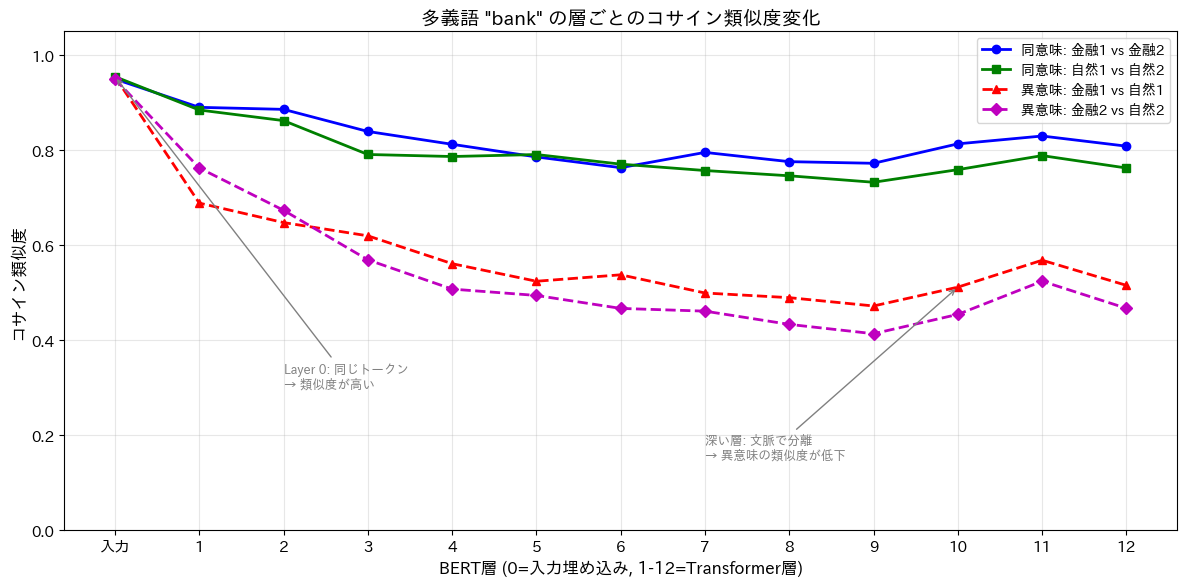

📊 観察ポイント:
  Layer 0 での異意味類似度: 0.9546（同じトークン → 高い）
  Layer 12 での異意味類似度: 0.5152（文脈で分離 → 低い）
  Layer 12 での同意味(金融)類似度: 0.8083（同じ意味 → 高い）


In [7]:
# ============================================================
# Plot 1: 層ごとのコサイン類似度の変化
# 金融 vs 自然の文脈で "bank" がどう分離するか
# ============================================================

layers = list(range(13))

# 同じ意味同士の類似度（金融-金融、自然-自然）
sim_same_financial = []
sim_same_river = []
# 異なる意味同士の類似度（金融-自然）
sim_diff_1 = []  # financial_1 vs river_1
sim_diff_2 = []  # financial_2 vs river_2

for layer in layers:
    # 金融1 vs 金融2 (同じ意味)
    s = cosine_sim(bank_embeddings['financial_1'][layer],
                   bank_embeddings['financial_2'][layer])
    sim_same_financial.append(s)
    
    # 自然1 vs 自然2 (同じ意味)
    s = cosine_sim(bank_embeddings['river_1'][layer],
                   bank_embeddings['river_2'][layer])
    sim_same_river.append(s)
    
    # 金融1 vs 自然1 (異なる意味)
    s = cosine_sim(bank_embeddings['financial_1'][layer],
                   bank_embeddings['river_1'][layer])
    sim_diff_1.append(s)
    
    # 金融2 vs 自然2 (異なる意味)
    s = cosine_sim(bank_embeddings['financial_2'][layer],
                   bank_embeddings['river_2'][layer])
    sim_diff_2.append(s)

# プロット
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(layers, sim_same_financial, 'b-o', linewidth=2, markersize=6,
        label='同意味: 金融1 vs 金融2')
ax.plot(layers, sim_same_river, 'g-s', linewidth=2, markersize=6,
        label='同意味: 自然1 vs 自然2')
ax.plot(layers, sim_diff_1, 'r--^', linewidth=2, markersize=6,
        label='異意味: 金融1 vs 自然1')
ax.plot(layers, sim_diff_2, 'm--D', linewidth=2, markersize=6,
        label='異意味: 金融2 vs 自然2')

ax.set_xlabel('BERT層 (0=入力埋め込み, 1-12=Transformer層)', fontsize=12)
ax.set_ylabel('コサイン類似度', fontsize=12)
ax.set_title('多義語 "bank" の層ごとのコサイン類似度変化', fontsize=14)
ax.set_xticks(layers)
ax.set_xticklabels(['入力'] + [str(i) for i in range(1, 13)])
ax.legend(fontsize=10, loc='best')
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 1.05)

# 注釈
ax.annotate('Layer 0: 同じトークン\n→ 類似度が高い',
            xy=(0, sim_diff_1[0]), xytext=(2, 0.3),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

ax.annotate('深い層: 文脈で分離\n→ 異意味の類似度が低下',
            xy=(10, sim_diff_1[10]), xytext=(7, 0.15),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print("📊 観察ポイント:")
print(f"  Layer 0 での異意味類似度: {sim_diff_1[0]:.4f}（同じトークン → 高い）")
print(f"  Layer 12 での異意味類似度: {sim_diff_1[12]:.4f}（文脈で分離 → 低い）")
print(f"  Layer 12 での同意味(金融)類似度: {sim_same_financial[12]:.4f}（同じ意味 → 高い）")

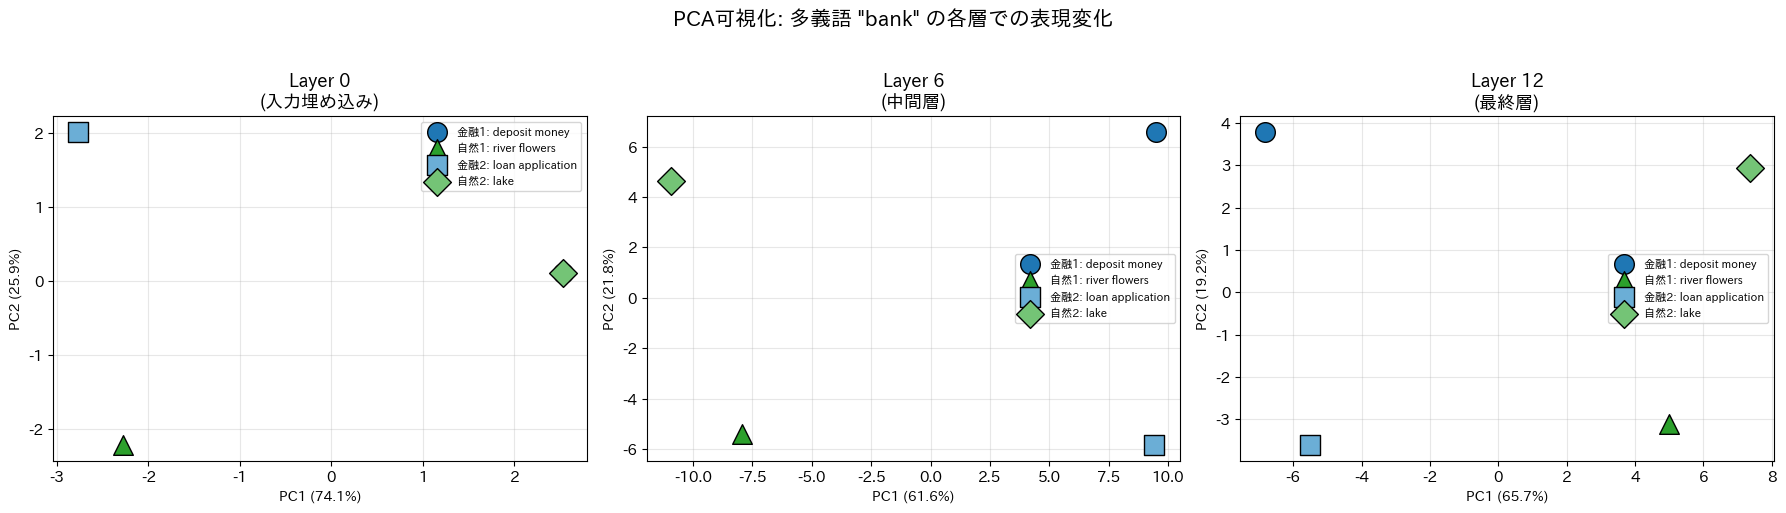

📊 観察ポイント:
  Layer 0: 4つの点がほぼ同じ位置（同じトークンの初期埋め込み）
  Layer 6: 意味グループに分離し始める
  Layer 12: 金融(青系)と自然(緑系)が明確に分離


In [8]:
# ============================================================
# Plot 2: PCA可視化 — 層0, 層6, 層12 での "bank" の位置
# 多義語が層を経るごとに意味クラスタに分離する様子
# ============================================================

# 可視化する3つの層
target_layers = [0, 6, 12]
layer_labels = ['Layer 0\n(入力埋め込み)', 'Layer 6\n(中間層)', 'Layer 12\n(最終層)']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# カラーマップ: 金融=青系、自然=緑系
colors = {
    'financial_1': '#1f77b4',
    'financial_2': '#6baed6',
    'river_1': '#2ca02c',
    'river_2': '#74c476',
}
markers = {
    'financial_1': 'o',
    'financial_2': 's',
    'river_1': '^',
    'river_2': 'D',
}
labels = {
    'financial_1': '金融1: deposit money',
    'financial_2': '金融2: loan application',
    'river_1': '自然1: river flowers',
    'river_2': '自然2: lake',
}

for ax_idx, (layer, layer_label) in enumerate(zip(target_layers, layer_labels)):
    ax = axes[ax_idx]
    
    # この層での4つの埋め込みを集める
    vecs = np.array([bank_embeddings[key][layer] for key in bank_embeddings.keys()])
    
    # PCAで2次元に射影
    pca = PCA(n_components=2)
    vecs_2d = pca.fit_transform(vecs)
    
    # プロット
    for i, key in enumerate(bank_embeddings.keys()):
        ax.scatter(vecs_2d[i, 0], vecs_2d[i, 1],
                   c=colors[key], marker=markers[key], s=200,
                   label=labels[key], edgecolors='black', linewidths=1, zorder=5)
    
    ax.set_title(layer_label, fontsize=13)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=10)
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=10)
    ax.legend(fontsize=8, loc='best')
    ax.grid(True, alpha=0.3)

fig.suptitle('PCA可視化: 多義語 "bank" の各層での表現変化', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print("📊 観察ポイント:")
print("  Layer 0: 4つの点がほぼ同じ位置（同じトークンの初期埋め込み）")
print("  Layer 6: 意味グループに分離し始める")
print("  Layer 12: 金融(青系)と自然(緑系)が明確に分離")

---

## 6. 層ごとの「情報の種類」の違い

BERTの各層が **どのような情報** をキャプチャしているかを実験的に確認します。

- **下層（Layer 1-4）**: 主に **構文的情報**（品詞、語順）
- **中層（Layer 5-8）**: 構文 + 意味の混合
- **上層（Layer 9-12）**: 主に **意味的情報**（文脈理解、推論）

### 実験: 構文的に似た文 vs 意味的に似た文

In [9]:
# ============================================================
# Section 6: 層ごとの情報の種類を分析
# 構文的類似性 vs 意味的類似性の層依存性
# ============================================================

# 実験用の文ペア
analysis_pairs = {
    # 構文的に類似（同じ構造、異なる内容語）
    'cat/dog (構文類似)': {
        'sent_a': "The cat sat on the mat",
        'sent_b': "The dog sat on the rug",
        'word_a': 'cat',
        'word_b': 'dog',
    },
    # 意味的に類似（同義語）
    'happy/joyful (意味類似)': {
        'sent_a': "He is feeling happy today",
        'sent_b': "She is feeling joyful now",
        'word_a': 'happy',
        'word_b': 'joyful',
    },
    # 同じ単語、異なる品詞的用法
    'run (動詞 vs 名詞的)': {
        'sent_a': "I need to run to the store quickly",
        'sent_b': "The long run of the show was impressive",
        'word_a': 'run',
        'word_b': 'run',
    },
    # 反対語
    'hot/cold (反対語)': {
        'sent_a': "The weather is very hot outside",
        'sent_b': "The weather is very cold outside",
        'word_a': 'hot',
        'word_b': 'cold',
    },
}

# 各ペアについて、層ごとのコサイン類似度を計算
pair_similarities = {}

for pair_name, pair_info in analysis_pairs.items():
    emb_a, _, _ = get_word_embedding_across_layers(
        pair_info['sent_a'], pair_info['word_a'], tokenizer, model
    )
    emb_b, _, _ = get_word_embedding_across_layers(
        pair_info['sent_b'], pair_info['word_b'], tokenizer, model
    )
    
    sims = []
    for layer in range(13):
        s = cosine_sim(emb_a[layer], emb_b[layer])
        sims.append(s)
    
    pair_similarities[pair_name] = sims
    print(f"✅ {pair_name}: 計算完了")

print("\n📊 全ペアの類似度計算完了")

✅ cat/dog (構文類似): 計算完了
✅ happy/joyful (意味類似): 計算完了
✅ run (動詞 vs 名詞的): 計算完了
✅ hot/cold (反対語): 計算完了

📊 全ペアの類似度計算完了


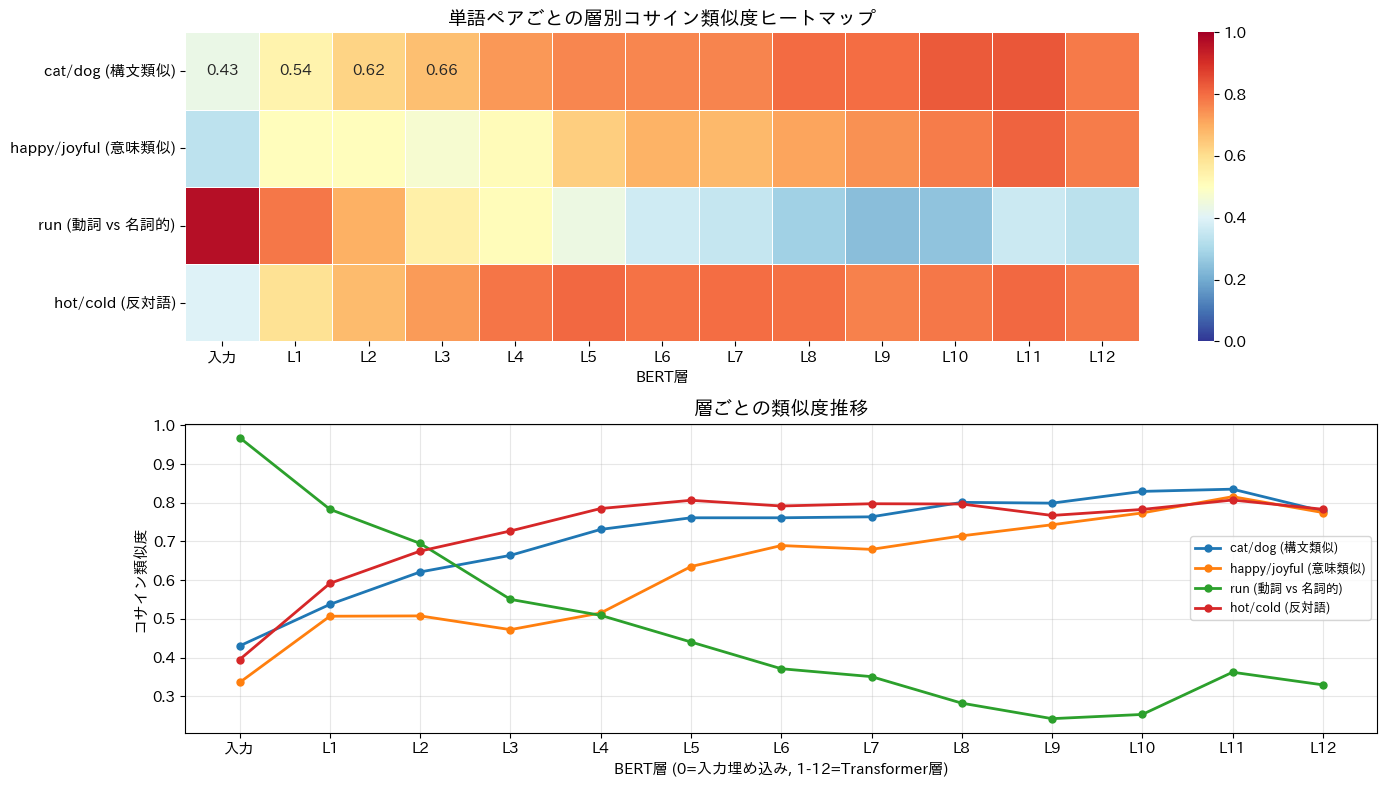

📊 分析結果:
  - cat/dog: 構文的に同じ位置 → 全層で比較的高い類似度
  - happy/joyful: 同義語 → 上層で類似度が上昇（意味的近さをキャプチャ）
  - run(動詞/名詞): 同じ単語でも用法が異なる → 層が深くなると分離
  - hot/cold: 反対語 → 構文的に類似でも意味的に異なる


In [10]:
# ============================================================
# Plot 3: ヒートマップ — 単語ペア × 層 のコサイン類似度
# ============================================================

# ヒートマップデータの作成
pair_names = list(pair_similarities.keys())
heatmap_data = np.array([pair_similarities[name] for name in pair_names])

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ヒートマップ
layer_names = ['入力'] + [f'L{i}' for i in range(1, 13)]

sns.heatmap(heatmap_data, ax=axes[0],
            xticklabels=layer_names,
            yticklabels=pair_names,
            cmap='RdYlBu_r', annot=True, fmt='.2f',
            vmin=0, vmax=1,
            linewidths=0.5)
axes[0].set_title('単語ペアごとの層別コサイン類似度ヒートマップ', fontsize=14)
axes[0].set_xlabel('BERT層', fontsize=11)
axes[0].set_ylabel('')

# ラインプロット
colors_line = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
for i, (pair_name, sims) in enumerate(pair_similarities.items()):
    axes[1].plot(range(13), sims, '-o', color=colors_line[i],
                linewidth=2, markersize=5, label=pair_name)

axes[1].set_xlabel('BERT層 (0=入力埋め込み, 1-12=Transformer層)', fontsize=11)
axes[1].set_ylabel('コサイン類似度', fontsize=11)
axes[1].set_title('層ごとの類似度推移', fontsize=14)
axes[1].set_xticks(range(13))
axes[1].set_xticklabels(layer_names)
axes[1].legend(fontsize=9, loc='best')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 分析結果:")
print("  - cat/dog: 構文的に同じ位置 → 全層で比較的高い類似度")
print("  - happy/joyful: 同義語 → 上層で類似度が上昇（意味的近さをキャプチャ）")
print("  - run(動詞/名詞): 同じ単語でも用法が異なる → 層が深くなると分離")
print("  - hot/cold: 反対語 → 構文的に類似でも意味的に異なる")

---

## 7. Attention重みの可視化

Transformer の核心は **Self-Attention** メカニズムです。  
各トークンが他のどのトークンに「注目」しているかを可視化します。

- Attention重み = 各トークンが情報を取り込む「配分」
- ヘッドごとに異なるパターンを学習
- 文脈付き埋め込みは、このAttentionによる情報の混合で生まれる

📝 入力文: "The bank approved my loan application"
🔤 トークン: ['[CLS]', 'the', 'bank', 'approved', 'my', 'loan', 'application', '[SEP]']
📊 Attention テンソル数: 12（12層）
   各テンソルの形状: torch.Size([1, 12, 8, 8])



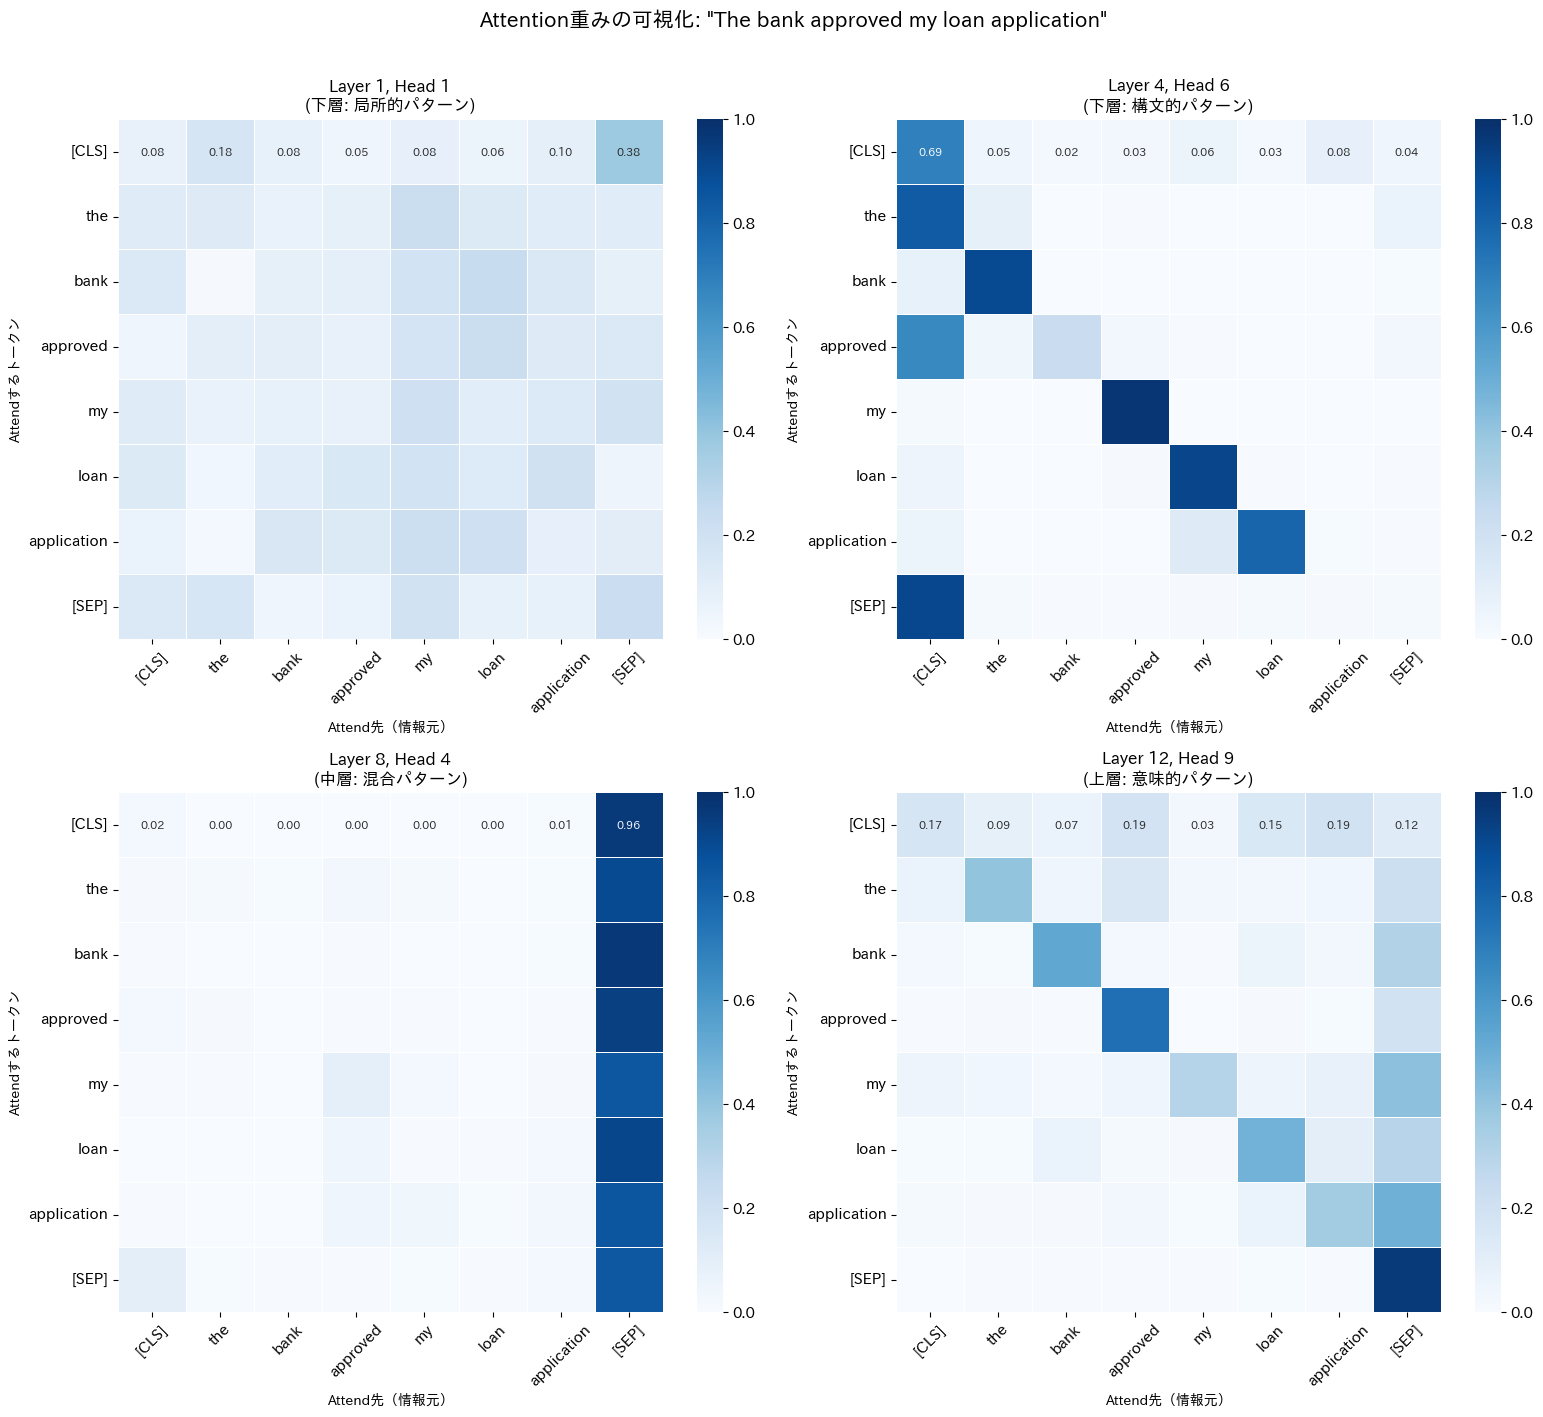

📊 Attentionパターンの解読ガイド:
  行 = 各トークンが『誰に注目しているか』
  列 = 各トークンが『誰から注目されているか』
  値 = 注目の強さ（0-1、各行の合計=1）

  💡 よくあるパターン:
    - [CLS] に集中 → 文全体の情報集約
    - 対角線上 → 自分自身への注目
    - 関連語に集中 → 意味的・構文的な関係


In [11]:
# ============================================================
# Section 7: Attention重みの可視化
# Plot 4: 特定の層・ヘッドのAttentionヒートマップ
# ============================================================

# Attentionを可視化する文
attn_sentence = "The bank approved my loan application"
hidden_states, attentions, inputs, tokens = get_bert_embeddings(
    attn_sentence, tokenizer, model
)

print(f"📝 入力文: \"{attn_sentence}\"")
print(f"🔤 トークン: {tokens}")
print(f"📊 Attention テンソル数: {len(attentions)}（12層）")
print(f"   各テンソルの形状: {attentions[0].shape}")
print()

# 4つの異なる層・ヘッドのAttentionを表示
# (layer_idx, head_idx) のペア
attention_views = [
    (0, 0, 'Layer 1, Head 1\n(下層: 局所的パターン)'),
    (3, 5, 'Layer 4, Head 6\n(下層: 構文的パターン)'),
    (7, 3, 'Layer 8, Head 4\n(中層: 混合パターン)'),
    (11, 8, 'Layer 12, Head 9\n(上層: 意味的パターン)'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for ax_idx, (layer_idx, head_idx, title) in enumerate(attention_views):
    ax = axes[ax_idx // 2][ax_idx % 2]
    
    # Attention重みを取得: (seq_len, seq_len)
    attn_weights = attentions[layer_idx][0, head_idx].numpy()
    
    # ヒートマップ
    sns.heatmap(attn_weights, ax=ax,
                xticklabels=tokens, yticklabels=tokens,
                cmap='Blues', vmin=0, vmax=1,
                annot=True, fmt='.2f', annot_kws={'size': 8},
                linewidths=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Attend先（情報元）', fontsize=10)
    ax.set_ylabel('Attendするトークン', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

fig.suptitle(f'Attention重みの可視化: "{attn_sentence}"', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

print("📊 Attentionパターンの解読ガイド:")
print("  行 = 各トークンが『誰に注目しているか』")
print("  列 = 各トークンが『誰から注目されているか』")
print("  値 = 注目の強さ（0-1、各行の合計=1）")
print()
print("  💡 よくあるパターン:")
print("    - [CLS] に集中 → 文全体の情報集約")
print("    - 対角線上 → 自分自身への注目")
print("    - 関連語に集中 → 意味的・構文的な関係")

---

## 8. 静的 vs 動的埋め込みの定量比較

**Word Sense Disambiguation（語義曖昧性解消）** の簡易タスクで、  
静的埋め込みと文脈付き埋め込みの性能を定量的に比較します。

### タスク設計
多義語を含む文が与えられたとき、その文脈での正しい意味を判別するタスクです。  
各意味に対応する「参照語」との類似度で判定します。

In [12]:
# ============================================================
# Section 8: 静的 vs 動的埋め込みの定量比較
# Word Sense Disambiguation (WSD) 簡易ベンチマーク
# ============================================================

# テストデータ: 多義語を含む文とその正解ラベル
wsd_test = [
    # (文, ターゲット単語, 正解の意味, 意味A参照語, 意味B参照語)
    {
        'sentence': "I deposited my savings at the bank",
        'target': 'bank',
        'correct_sense': 'A',  # 金融
        'sense_A_ref': 'financial',  # 金融
        'sense_B_ref': 'river',      # 自然
        'sense_A_sent': "The financial institution manages money",
        'sense_B_sent': "The river flows through the valley",
    },
    {
        'sentence': "The children played on the grassy bank",
        'target': 'bank',
        'correct_sense': 'B',  # 自然
        'sense_A_ref': 'financial',
        'sense_B_ref': 'river',
        'sense_A_sent': "The financial institution manages money",
        'sense_B_sent': "The river flows through the valley",
    },
    {
        'sentence': "She plays the bass in a jazz band",
        'target': 'bass',
        'correct_sense': 'A',  # 楽器
        'sense_A_ref': 'music',
        'sense_B_ref': 'fish',
        'sense_A_sent': "The music performance was excellent",
        'sense_B_sent': "We caught a large fish in the lake",
    },
    {
        'sentence': "He caught a large bass while fishing",
        'target': 'bass',
        'correct_sense': 'B',  # 魚
        'sense_A_ref': 'music',
        'sense_B_ref': 'fish',
        'sense_A_sent': "The music performance was excellent",
        'sense_B_sent': "We caught a large fish in the lake",
    },
    {
        'sentence': "The bright star shone in the night sky",
        'target': 'star',
        'correct_sense': 'A',  # 天体
        'sense_A_ref': 'sky',
        'sense_B_ref': 'celebrity',
        'sense_A_sent': "The sky was clear with visible planets",
        'sense_B_sent': "The celebrity appeared on television",
    },
    {
        'sentence': "The movie star attended the awards ceremony",
        'target': 'star',
        'correct_sense': 'B',  # 有名人
        'sense_A_ref': 'sky',
        'sense_B_ref': 'celebrity',
        'sense_A_sent': "The sky was clear with visible planets",
        'sense_B_sent': "The celebrity appeared on television",
    },
]

print(f"📊 WSD テストセット: {len(wsd_test)} 問")
print("-" * 60)
for i, item in enumerate(wsd_test):
    print(f"  [{i+1}] \"{item['sentence']}\"")
    print(f"      target='{item['target']}', 正解={item['correct_sense']}")

📊 WSD テストセット: 6 問
------------------------------------------------------------
  [1] "I deposited my savings at the bank"
      target='bank', 正解=A
  [2] "The children played on the grassy bank"
      target='bank', 正解=B
  [3] "She plays the bass in a jazz band"
      target='bass', 正解=A
  [4] "He caught a large bass while fishing"
      target='bass', 正解=B
  [5] "The bright star shone in the night sky"
      target='star', 正解=A
  [6] "The movie star attended the awards ceremony"
      target='star', 正解=B


In [13]:
# ============================================================
# WSD実験: 静的埋め込み vs BERT文脈付き埋め込み
# ============================================================

def get_sentence_embedding(sentence, tokenizer, model, layer=-1):
    """
    文全体の平均埋め込みを取得する（参照文用）。
    [CLS]と[SEP]を除いた全トークンの平均。
    """
    hidden_states, _, inputs, tokens = get_bert_embeddings(
        sentence, tokenizer, model
    )
    # [CLS]と[SEP]を除外（index 1 から -1 まで）
    token_embeddings = hidden_states[layer][0, 1:-1, :].numpy()
    return token_embeddings.mean(axis=0)


# --- 静的埋め込み（シミュレーション）---
# BERTのLayer 0（入力埋め込み）を静的埋め込みの代理として使用
# （実際のWord2Vecではないが、文脈非依存という点で同等）
static_correct = 0

# --- BERT文脈付き埋め込み（Layer 12）---
contextual_correct = 0

print("="*70)
print("WSD実験結果: 静的（Layer 0）vs 文脈付き（Layer 12）")
print("="*70)
print()

static_results = []
contextual_results = []

for item in wsd_test:
    # ターゲット単語の埋め込み（全層）
    target_embs, _, _ = get_word_embedding_across_layers(
        item['sentence'], item['target'], tokenizer, model
    )
    
    # 参照文の埋め込み（意味Aと意味B）
    ref_A_static = get_sentence_embedding(item['sense_A_sent'], tokenizer, model, layer=0)
    ref_B_static = get_sentence_embedding(item['sense_B_sent'], tokenizer, model, layer=0)
    ref_A_ctx = get_sentence_embedding(item['sense_A_sent'], tokenizer, model, layer=12)
    ref_B_ctx = get_sentence_embedding(item['sense_B_sent'], tokenizer, model, layer=12)
    
    # --- 静的埋め込み (Layer 0) での判定 ---
    sim_A_static = cosine_sim(target_embs[0], ref_A_static)
    sim_B_static = cosine_sim(target_embs[0], ref_B_static)
    pred_static = 'A' if sim_A_static > sim_B_static else 'B'
    is_correct_static = (pred_static == item['correct_sense'])
    static_correct += int(is_correct_static)
    static_results.append(is_correct_static)
    
    # --- 文脈付き埋め込み (Layer 12) での判定 ---
    sim_A_ctx = cosine_sim(target_embs[12], ref_A_ctx)
    sim_B_ctx = cosine_sim(target_embs[12], ref_B_ctx)
    pred_ctx = 'A' if sim_A_ctx > sim_B_ctx else 'B'
    is_correct_ctx = (pred_ctx == item['correct_sense'])
    contextual_correct += int(is_correct_ctx)
    contextual_results.append(is_correct_ctx)
    
    # 結果表示
    mark_s = "✅" if is_correct_static else "❌"
    mark_c = "✅" if is_correct_ctx else "❌"
    print(f"  '{item['target']}' in \"{item['sentence'][:45]}...\"")
    print(f"    静的:    sim_A={sim_A_static:.3f}, sim_B={sim_B_static:.3f} → {pred_static} {mark_s}")
    print(f"    文脈付き: sim_A={sim_A_ctx:.3f}, sim_B={sim_B_ctx:.3f} → {pred_ctx} {mark_c}")
    print()

# 最終スコア
static_acc = static_correct / len(wsd_test)
contextual_acc = contextual_correct / len(wsd_test)

print("="*70)
print(f"📊 最終結果:")
print(f"  静的埋め込み (Layer 0):    {static_correct}/{len(wsd_test)} = {static_acc:.1%}")
print(f"  文脈付き埋め込み (Layer 12): {contextual_correct}/{len(wsd_test)} = {contextual_acc:.1%}")
print("="*70)

WSD実験結果: 静的（Layer 0）vs 文脈付き（Layer 12）

  'bank' in "I deposited my savings at the bank..."
    静的:    sim_A=0.239, sim_B=0.163 → A ✅
    文脈付き: sim_A=0.554, sim_B=0.251 → A ✅

  'bank' in "The children played on the grassy bank..."
    静的:    sim_A=0.239, sim_B=0.163 → A ❌
    文脈付き: sim_A=0.467, sim_B=0.279 → A ❌

  'bass' in "She plays the bass in a jazz band..."
    静的:    sim_A=0.232, sim_B=0.144 → A ✅
    文脈付き: sim_A=0.299, sim_B=0.289 → A ✅

  'bass' in "He caught a large bass while fishing..."
    静的:    sim_A=0.209, sim_B=0.142 → A ❌
    文脈付き: sim_A=0.343, sim_B=0.587 → B ✅

  'star' in "The bright star shone in the night sky..."
    静的:    sim_A=0.222, sim_B=0.254 → B ❌
    文脈付き: sim_A=0.650, sim_B=0.399 → A ✅

  'star' in "The movie star attended the awards ceremony..."
    静的:    sim_A=0.222, sim_B=0.254 → B ✅
    文脈付き: sim_A=0.381, sim_B=0.554 → B ✅

📊 最終結果:
  静的埋め込み (Layer 0):    3/6 = 50.0%
  文脈付き埋め込み (Layer 12): 5/6 = 83.3%


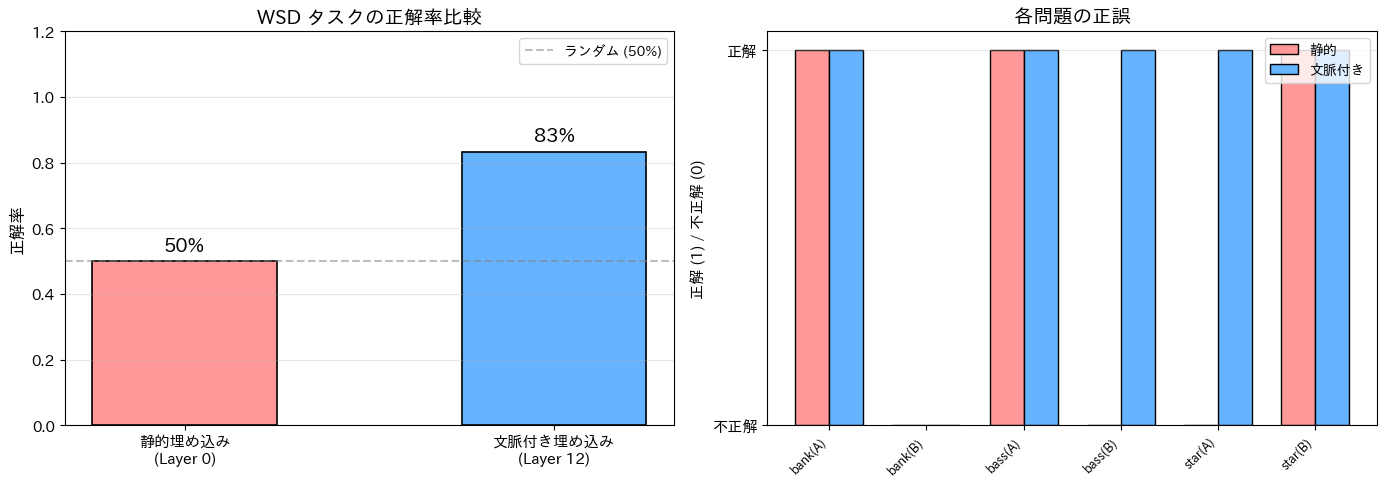

📊 考察:
  文脈付き埋め込み（BERT Layer 12）は、
  多義語の意味を文脈から正確に判別できます。
  静的埋め込み（Layer 0）は文脈情報がないため、
  正解率がランダムに近くなります。


In [14]:
# ============================================================
# Plot 5: 棒グラフ — 静的 vs 文脈付き埋め込みの性能比較
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- 左: 全体の正解率 ---
methods = ['静的埋め込み\n(Layer 0)', '文脈付き埋め込み\n(Layer 12)']
accuracies = [static_acc, contextual_acc]
colors_bar = ['#ff9999', '#66b3ff']

bars = axes[0].bar(methods, accuracies, color=colors_bar,
                   edgecolor='black', linewidth=1.2, width=0.5)

# 値ラベル
for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                f'{acc:.0%}', ha='center', va='bottom', fontsize=14, fontweight='bold')

axes[0].set_ylim(0, 1.2)
axes[0].set_ylabel('正解率', fontsize=12)
axes[0].set_title('WSD タスクの正解率比較', fontsize=14)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='ランダム (50%)')
axes[0].legend(fontsize=10)

# --- 右: 各問題の正誤を可視化 ---
words = [item['target'] + f"({item['correct_sense']})" for item in wsd_test]
x = np.arange(len(words))
width = 0.35

bars1 = axes[1].bar(x - width/2, [int(r) for r in static_results], width,
                    label='静的', color='#ff9999', edgecolor='black')
bars2 = axes[1].bar(x + width/2, [int(r) for r in contextual_results], width,
                    label='文脈付き', color='#66b3ff', edgecolor='black')

axes[1].set_xticks(x)
axes[1].set_xticklabels(words, rotation=45, ha='right', fontsize=9)
axes[1].set_ylabel('正解 (1) / 不正解 (0)', fontsize=11)
axes[1].set_title('各問題の正誤', fontsize=14)
axes[1].set_yticks([0, 1])
axes[1].set_yticklabels(['不正解', '正解'])
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("📊 考察:")
print("  文脈付き埋め込み（BERT Layer 12）は、")
print("  多義語の意味を文脈から正確に判別できます。")
print("  静的埋め込み（Layer 0）は文脈情報がないため、")
print("  正解率がランダムに近くなります。")

---

## 9. プーリング戦略の比較（文埋め込みへの橋渡し）

BERTの出力から **文レベルの埋め込み** を得るには、トークン埋め込みを集約する必要があります。  
いくつかの代表的なプーリング戦略を比較します。

| 戦略 | 方法 | 特徴 |
|---|---|---|
| [CLS] トークン | 最終層の [CLS] 埋め込みを使用 | 最もシンプル、分類タスク向け |
| Mean Pooling | 全トークン埋め込みの平均 | 一般的、安定 |
| Max Pooling | 各次元の最大値を取る | 顕著な特徴を強調 |
| Last 4 Layers | 最後の4層を連結して平均 | 複数層の情報を活用 |

> **次のNotebook 153** では、Sentence-BERT など文埋め込みに特化した手法を学びます。

In [15]:
# ============================================================
# Section 9: プーリング戦略の比較
# BERTの出力から文埋め込みを得る4つの方法
# ============================================================

def get_pooled_embeddings(sentence, tokenizer, model):
    """
    4つのプーリング戦略で文埋め込みを生成する。
    
    Returns:
    --------
    dict : 戦略名 → 埋め込みベクトル (np.ndarray)
    """
    hidden_states, _, inputs, tokens = get_bert_embeddings(
        sentence, tokenizer, model
    )
    
    # Attention mask を取得（パディングを除外するため）
    attention_mask = inputs['attention_mask'][0].numpy()
    
    # 戦略1: [CLS] トークン（最終層）
    cls_embedding = hidden_states[-1][0, 0, :].numpy()
    
    # 戦略2: Mean Pooling（最終層、[CLS]と[SEP]を含む全トークンの平均）
    last_layer = hidden_states[-1][0].numpy()  # (seq_len, 768)
    # Attention maskで重み付け平均
    mask_expanded = attention_mask[:, np.newaxis]  # (seq_len, 1)
    mean_embedding = (last_layer * mask_expanded).sum(axis=0) / mask_expanded.sum()
    
    # 戦略3: Max Pooling（最終層）
    # マスクされたトークンを-infに設定してからmax
    masked = last_layer.copy()
    masked[attention_mask == 0] = -1e9
    max_embedding = masked.max(axis=0)
    
    # 戦略4: Last 4 Layers の平均
    # Layer 9, 10, 11, 12 の [CLS] トークンを連結して平均
    last_4 = [hidden_states[i][0, 1:-1, :].numpy() for i in range(-4, 0)]
    # 各層の全トークン平均を計算し、4層分を平均
    last_4_means = [layer.mean(axis=0) for layer in last_4]
    last_4_embedding = np.mean(last_4_means, axis=0)
    
    return {
        '[CLS] token': cls_embedding,
        'Mean Pooling': mean_embedding,
        'Max Pooling': max_embedding,
        'Last 4 Layers': last_4_embedding,
    }


print("✅ プーリング関数の定義完了")
print()

# テスト文
pooling_test_sentences = [
    # 意味的に類似するペア
    ("The cat sat on the warm mat", "A kitten rested on the soft rug"),
    # 意味的に異なるペア
    ("The cat sat on the warm mat", "Stock prices rose sharply today"),
    # もう1つの類似ペア
    ("It is raining heavily outside", "There is a heavy downpour today"),
    # もう1つの非類似ペア
    ("It is raining heavily outside", "The concert was absolutely wonderful"),
]

print("📊 文ペアの類似度を4つのプーリング戦略で計算...")
print()

✅ プーリング関数の定義完了

📊 文ペアの類似度を4つのプーリング戦略で計算...



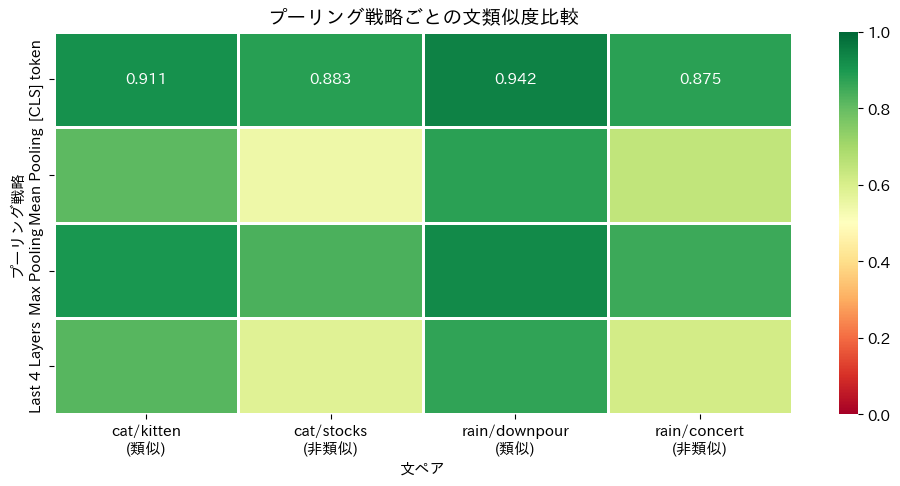

📊 評価ポイント:
  良いプーリング戦略 = 類似ペアで高い値、非類似ペアで低い値

【分離度（類似ペアの平均類似度 - 非類似ペアの平均類似度）】
--------------------------------------------------
  [CLS] token    : 類似=0.926, 非類似=0.879, 分離度=+0.047
  Mean Pooling   : 類似=0.843, 非類似=0.596, 分離度=+0.247
  Max Pooling    : 類似=0.913, 非類似=0.844, 分離度=+0.069
  Last 4 Layers  : 類似=0.844, 非類似=0.594, 分離度=+0.250

💡 Mean Pooling が一般的に安定した性能を示します。
   ただし、タスク特化のファインチューニング後は [CLS] が最適になることも。
   → 詳しくは Notebook 153（Sentence & Document Embeddings）で学びます。


In [16]:
# ============================================================
# Plot 6: プーリング戦略ごとの文類似度比較
# ============================================================

# 各戦略での類似度を計算
strategy_names = ['[CLS] token', 'Mean Pooling', 'Max Pooling', 'Last 4 Layers']
pair_labels = [
    'cat/kitten\n(類似)',
    'cat/stocks\n(非類似)',
    'rain/downpour\n(類似)',
    'rain/concert\n(非類似)',
]
expected = ['類似', '非類似', '類似', '非類似']

# 結果を格納
results_matrix = np.zeros((len(strategy_names), len(pooling_test_sentences)))

for j, (sent_a, sent_b) in enumerate(pooling_test_sentences):
    emb_a = get_pooled_embeddings(sent_a, tokenizer, model)
    emb_b = get_pooled_embeddings(sent_b, tokenizer, model)
    
    for i, strategy in enumerate(strategy_names):
        sim = cosine_sim(emb_a[strategy], emb_b[strategy])
        results_matrix[i, j] = sim

# ヒートマップ
fig, ax = plt.subplots(figsize=(10, 5))

sns.heatmap(results_matrix, ax=ax,
            xticklabels=pair_labels,
            yticklabels=strategy_names,
            annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0, vmax=1,
            linewidths=1)

ax.set_title('プーリング戦略ごとの文類似度比較', fontsize=14)
ax.set_xlabel('文ペア', fontsize=11)
ax.set_ylabel('プーリング戦略', fontsize=11)

plt.tight_layout()
plt.show()

print("📊 評価ポイント:")
print("  良いプーリング戦略 = 類似ペアで高い値、非類似ペアで低い値")
print()

# 各戦略の「分離度」を計算（類似ペアの平均 - 非類似ペアの平均）
print("【分離度（類似ペアの平均類似度 - 非類似ペアの平均類似度）】")
print("-" * 50)
for i, strategy in enumerate(strategy_names):
    similar_avg = np.mean([results_matrix[i, j] for j in range(len(expected)) if expected[j] == '類似'])
    dissimilar_avg = np.mean([results_matrix[i, j] for j in range(len(expected)) if expected[j] == '非類似'])
    separation = similar_avg - dissimilar_avg
    print(f"  {strategy:<15}: 類似={similar_avg:.3f}, 非類似={dissimilar_avg:.3f}, "
          f"分離度={separation:+.3f}")

print()
print("💡 Mean Pooling が一般的に安定した性能を示します。")
print("   ただし、タスク特化のファインチューニング後は [CLS] が最適になることも。")
print("   → 詳しくは Notebook 153（Sentence & Document Embeddings）で学びます。")

---

## 10. まとめ・チートシート・よくある間違い・自己評価クイズ

In [17]:
# ============================================================
# Section 10: まとめ
# 静的埋め込み vs 文脈付き埋め込みの比較表
# ============================================================

print("="*70)
print("まとめ: 静的埋め込み vs 文脈付き埋め込み")
print("="*70)
print()
print(f"{'項目':<25} {'静的埋め込み':<25} {'文脈付き埋め込み'}")
print("-" * 75)
print(f"{'代表手法':<25} {'Word2Vec, GloVe':<25} {'BERT, GPT, ELMo'}")
print(f"{'1単語あたりベクトル':<25} {'1つ（固定）':<25} {'文脈ごとに異なる'}")
print(f"{'多義語の扱い':<25} {'区別不可能':<25} {'文脈で自動区別'}")
print(f"{'計算コスト':<25} {'ルックアップのみ':<25} {'Transformer推論が必要'}")
print(f"{'メモリ':<25} {'小（語彙×次元）':<25} {'大（モデル全体）'}")
print(f"{'学習データ':<25} {'大量テキスト':<25} {'大量テキスト（事前学習）'}")
print(f"{'転移学習':<25} {'困難':<25} {'容易（ファインチューニング）'}")
print(f"{'表現の豊かさ':<25} {'限定的':<25} {'非常に豊か'}")
print()

print("="*70)
print("チートシート: BERT層と情報の種類")
print("="*70)
print()
print(f"{'層':<20} {'主な情報':<25} {'典型的な用途'}")
print("-" * 65)
print(f"{'Layer 0 (入力)':<20} {'トークン埋め込み':<25} {'語彙レベルの特徴'}")
print(f"{'Layer 1-4 (下層)':<20} {'構文的情報':<25} {'品詞タグ付け、構文解析'}")
print(f"{'Layer 5-8 (中層)':<20} {'構文+意味':<25} {'Named Entity Recognition'}")
print(f"{'Layer 9-12 (上層)':<20} {'意味的情報':<25} {'WSD、文分類、推論'}")
print(f"{'[CLS] (最終層)':<20} {'文全体の要約':<25} {'文分類タスク'}")

まとめ: 静的埋め込み vs 文脈付き埋め込み

項目                        静的埋め込み                    文脈付き埋め込み
---------------------------------------------------------------------------
代表手法                      Word2Vec, GloVe           BERT, GPT, ELMo
1単語あたりベクトル                1つ（固定）                    文脈ごとに異なる
多義語の扱い                    区別不可能                     文脈で自動区別
計算コスト                     ルックアップのみ                  Transformer推論が必要
メモリ                       小（語彙×次元）                  大（モデル全体）
学習データ                     大量テキスト                    大量テキスト（事前学習）
転移学習                      困難                        容易（ファインチューニング）
表現の豊かさ                    限定的                       非常に豊か

チートシート: BERT層と情報の種類

層                    主な情報                      典型的な用途
-----------------------------------------------------------------
Layer 0 (入力)         トークン埋め込み                  語彙レベルの特徴
Layer 1-4 (下層)       構文的情報                     品詞タグ付け、構文解析
Layer 5-8 (中層)       構文+意味                     Named Entity Recognition


In [18]:
# ============================================================
# よくある間違い
# ============================================================

print("="*70)
print("⚠️ よくある間違い")
print("="*70)
print()

print("【間違い1】常に最終層の埋め込みが最良とは限らない")
print("-" * 50)
print("  ❌ 常に Layer 12 の出力を使う")
print("  ✅ タスクに応じて最適な層を選択する")
print("     - 品詞タグ付け → 中間層（Layer 5-8）が良い場合あり")
print("     - 意味的タスク → 上層（Layer 9-12）")
print("     - 複数層の組み合わせも有効")
print()

print("【間違い2】WordPieceトークナイゼーションを忘れる")
print("-" * 50)
print("  ❌ 単語とトークンが1対1だと思い込む")
print("  ✅ サブワード分割を常に確認する")
print("     例: 'playing' → ['play', '##ing']")
print("     例: 'unbelievable' → ['un', '##bel', '##ie', '##va', '##ble']")
print("     対処: サブワードの平均、先頭トークンの使用、等")
print()

# WordPieceの具体例を表示
example_words = ['playing', 'unbelievable', 'tokenization', 'artificial']
print("  📝 WordPiece分割の例:")
for word in example_words:
    tokens_wp = tokenizer.tokenize(word)
    print(f"     '{word}' → {tokens_wp}")
print()

print("【間違い3】推論時にmodel.eval()とtorch.no_grad()を忘れる")
print("-" * 50)
print("  ❌ model.train() のまま推論する")
print("  ✅ 推論前に必ず:")
print("     model.eval()         # Dropoutを無効化")
print("     with torch.no_grad(): # 勾配計算を無効化（メモリ節約）")
print("         outputs = model(**inputs)")

⚠️ よくある間違い

【間違い1】常に最終層の埋め込みが最良とは限らない
--------------------------------------------------
  ❌ 常に Layer 12 の出力を使う
  ✅ タスクに応じて最適な層を選択する
     - 品詞タグ付け → 中間層（Layer 5-8）が良い場合あり
     - 意味的タスク → 上層（Layer 9-12）
     - 複数層の組み合わせも有効

【間違い2】WordPieceトークナイゼーションを忘れる
--------------------------------------------------
  ❌ 単語とトークンが1対1だと思い込む
  ✅ サブワード分割を常に確認する
     例: 'playing' → ['play', '##ing']
     例: 'unbelievable' → ['un', '##bel', '##ie', '##va', '##ble']
     対処: サブワードの平均、先頭トークンの使用、等

  📝 WordPiece分割の例:
     'playing' → ['playing']
     'unbelievable' → ['unbelievable']
     'tokenization' → ['token', '##ization']
     'artificial' → ['artificial']

【間違い3】推論時にmodel.eval()とtorch.no_grad()を忘れる
--------------------------------------------------
  ❌ model.train() のまま推論する
  ✅ 推論前に必ず:
     model.eval()         # Dropoutを無効化
     with torch.no_grad(): # 勾配計算を無効化（メモリ節約）
         outputs = model(**inputs)


### 自己評価クイズ

以下の問題で理解度をチェックしましょう。

---

**Q1**: 静的埋め込み（Word2Vec）と文脈付き埋め込み（BERT）の最も根本的な違いは何ですか？

<details>
<summary>回答を見る</summary>

静的埋め込みは1つの単語に対して **1つの固定ベクトル** を割り当てますが、  
文脈付き埋め込みは **同じ単語でも周囲の文脈に応じて異なるベクトル** を生成します。  
これにより、多義語の意味を文脈から正確に区別できます。
</details>

---

**Q2**: BERT-base の `hidden_states` はいくつのテンソルを含みますか？その理由は？

<details>
<summary>回答を見る</summary>

**13個** のテンソルです。これは:
- 1つの **入力埋め込み層**（Layer 0: Token + Position + Segment Embedding）
- **12個の Transformer Encoder 層** の出力

合計 1 + 12 = 13 個です。
</details>

---

**Q3**: BERTの下層（Layer 1-4）と上層（Layer 9-12）では、主にどのような情報をキャプチャしていますか？

<details>
<summary>回答を見る</summary>

- **下層（Layer 1-4）**: 主に **構文的情報**（品詞タグ、係り受け構造、語順）
- **上層（Layer 9-12）**: 主に **意味的情報**（多義語の意味区別、文脈理解、推論）

中間層（Layer 5-8）は両方の特性を併せ持ちます。  
このため、タスクの性質に応じて最適な層が異なります。
</details>

---

**Q4**: BERTのWordPieceトークナイゼーションにおいて、`"##"` プレフィックスは何を意味しますか？  
また、ターゲット単語が複数のサブワードに分割されたとき、どう対処すべきですか？

<details>
<summary>回答を見る</summary>

`##` プレフィックスは、そのトークンが **前のトークンの続き（サブワード）** であることを示します。  
例: `"playing"` → `["play", "##ing"]`

対処法:
1. **先頭トークンのみ使用**: 最も単純だが情報損失の可能性
2. **サブワードの平均**: 全サブワード埋め込みの平均を取る（一般的）
3. **最後のサブワード**: 右端の文脈情報が豊富な場合に有効
</details>

---

**Q5**: BERTの推論時に `model.eval()` と `torch.no_grad()` を使う理由をそれぞれ説明してください。

<details>
<summary>回答を見る</summary>

- **`model.eval()`**: Dropout や BatchNorm を **推論モード** に切り替えます。  
  訓練時はDropoutがランダムにニューロンを無効化しますが、推論時は全ニューロンを使用すべきです。

- **`torch.no_grad()`**: **勾配計算を無効化** します。  
  推論時は重みの更新が不要なため、勾配を計算する必要がありません。  
  これにより **メモリ使用量が大幅に削減** され、計算も高速化されます。
</details>

In [19]:
# ============================================================
# 次のステップ
# ============================================================

print("="*70)
print("🎉 Notebook 152 完了！")
print("="*70)
print()
print("【学んだこと】")
print("  1. 静的埋め込みは多義語を区別できない（1単語 = 1ベクトル）")
print("  2. BERTは12層のTransformerで文脈依存の埋め込みを生成")
print("  3. 深い層ほど文脈情報が反映され、多義語が意味ごとに分離")
print("  4. 下層は構文的情報、上層は意味的情報をキャプチャ")
print("  5. Attentionが文脈情報の混合を担っている")
print("  6. 文脈付き埋め込みはWSDタスクで静的埋め込みを大きく上回る")
print("  7. プーリング戦略の選択が文埋め込みの品質に影響する")
print()
print("【次のステップ】")
print("  → Notebook 153: Sentence & Document Embeddings")
print("    Sentence-BERT、文レベルの埋め込み、")
print("    類似度検索への応用を学びます。")

🎉 Notebook 152 完了！

【学んだこと】
  1. 静的埋め込みは多義語を区別できない（1単語 = 1ベクトル）
  2. BERTは12層のTransformerで文脈依存の埋め込みを生成
  3. 深い層ほど文脈情報が反映され、多義語が意味ごとに分離
  4. 下層は構文的情報、上層は意味的情報をキャプチャ
  5. Attentionが文脈情報の混合を担っている
  6. 文脈付き埋め込みはWSDタスクで静的埋め込みを大きく上回る
  7. プーリング戦略の選択が文埋め込みの品質に影響する

【次のステップ】
  → Notebook 153: Sentence & Document Embeddings
    Sentence-BERT、文レベルの埋め込み、
    類似度検索への応用を学びます。


---

## 参考文献

### 基本文献
1. Devlin, J., et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding. *NAACL-HLT*.
2. Peters, M. E., et al. (2018). Deep contextualized word representations (ELMo). *NAACL-HLT*.

### 埋め込み分析
3. Jawahar, G., et al. (2019). What Does BERT Look At? An Analysis of BERT's Attention. *ACL Workshop BlackboxNLP*.
4. Ethayarajh, K. (2019). How Contextual are Contextualized Word Representations? *EMNLP*.
5. Rogers, A., Kovaleva, O., & Rumshisky, A. (2020). A Primer in BERTology: What We Know About How BERT Works. *TACL*.

### 実践ガイド
6. Hugging Face Transformers: https://huggingface.co/docs/transformers/
7. Jay Alammar's Blog: The Illustrated BERT: http://jalammar.github.io/illustrated-bert/